In [ ]:

import pytest
import xara
import veux
from xsection.library._asbi import create_asbi, SingleCellGirder
from xsection.analysis import WarpingAnalysis
from xsection._benchmarks import load_shape

# Gruttmann, Wagner (2001)
shape = load_shape("G02", mesh_type="T6", mesh_scale=1)

E = shape.material["E"]
G = shape.material["G"]
assert shape.flange_area()+shape.web_area() == pytest.approx(shape.area, rel=1e-1)


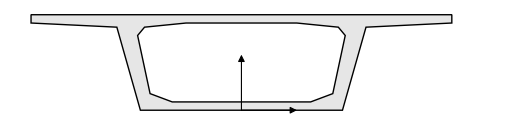

In [2]:
veux.draw_shape(shape, origin=True)

In [3]:

sv = WarpingAnalysis(shape)

print(sv.moment_vector())
print(sv.centroid()*E*shape.area)

[1.97619698e-14 2.43105000e+02]
[1.97619698e-14 2.43105000e+02]


In [4]:
import xara 
print(xara.FrameSection("Elastic", shape).normalized_constants(shape.material))

NormalizedConstants(A=11.279999999999962,
    Iy=437.78580637184314,
    Iz=169.8876125000035,
    Iyz=None,
    Ay=6.762946219175289,
    Az=2.610601474196682,
    J=59.12189994574369)



## Center of shear

wrt the bottom of the soffit

In [5]:

scy,scz = shape._analysis.shear_center()
assert scy == pytest.approx(0, rel=1e-3)
assert scz == pytest.approx(1.569, rel=1e-3)


In [ ]:
assert sv.twist_rigidity()/shape.material["G"] == pytest.approx(42.487, rel=5e-2)


In [7]:
tr = sv.create_trace(form="energetic")
ky, kz = tr.sce()
assert ky == pytest.approx(0.5993, rel=1e-3)
assert kz == pytest.approx(0.2311, rel=1e-2)

# Warping constant, value from [3]
shape = shape.translate([-scy,-scz]) # -sv.twist_center()
Cw = shape.cww()[0,0]
# Cw = sv.twist_warp_inertia()
assert Cw/E == pytest.approx(62.788, rel=1e-2)

## References


2. Paradiso, Massimo, Salvatore Sessa, Nicolò Vaiana, Francesco Marmo, and Luciano Rosati. 
    "Shear Properties of Isotropic and Homogeneous Beam-like Solids Having Arbitrary Cross Sections."
    International Journal of Solids and Structures 216 (May 2021): 231–49. 
    https://doi.org/10.1016/j.ijsolstr.2021.01.012.
3. Roccia, Bruno A., Carmina Alturria Lanzardo, Fernando D. Mazzone, and Cristian G. Gebhardt. 
    "On the Homogeneous Torsion Problem for Heterogeneous and Orthotropic Cross-Sections: Theoretical and Numerical Aspects."
    Applied Numerical Mathematics 201 (July 2024): 579–607. 
    https://doi.org/10.1016/j.apnum.2024.03.017.